In [16]:
# def Admitanca(w, omega, Phi, modal_shapes_l_limit = 0, modal_shapes_u_limit = 2,o_l_limit = 0, o_u_limit = 4, i_l_limit = 0, i_u_limit = 3):
#     """Funkcjia vzame vektor lastnih vrednosti w in Normiran vektor Lastnih oblik. Z definicijo mej določimo kaj je zajeto kot input in output

#     Args:
#         w (vector): vektor lastnih vrednosti
#         omega (vector): vektor obravnavanih frekvenc
#         Phi (matrix): kvadratna matrika lastnih oblik
#         modal_shapes_l_limit (int, optional): spodnja meja upoštevanih modeshapes. Defaults to 0.
#         modal_shapes_u_limit (int, optional): zgornja meja upoštevanih modeshapes. Defaults to 2.
#         o_l_limit (int, optional): Output lower limit. Defaults to 0.
#         o_u_limit (int, optional): Output upperr limit. Defaults to 4.
#         i_l_limit (int, optional): Input lower limit. Defaults to 0.
#         i_u_limit (int, optional): Input upperr limit. Defaults to 3.
#     """
    
#     omega_r = w[modal_shapes_l_limit:modal_shapes_u_limit] # lastne frekvence
#     Phi_output = Phi[o_l_limit:o_u_limit,modal_shapes_l_limit:modal_shapes_u_limit].copy()
#     Phi_input = Phi[i_l_limit:i_u_limit, modal_shapes_l_limit:modal_shapes_u_limit].copy()
    
#     Y_2_einsum = np.einsum('om, im, fm -> foi', Phi_output, Phi_input, 1. / (-omega[:,None]**2 + omega_r**2))
#     print(f'Admitanca -> shape: {Y_2_einsum.shape}')
#     return Y_2_einsum

**Enačbe za 3 DoF in izpisana enačba za telo 1**

$$m_1 \ddot{x}_1 
+ (c_1 + c_2) \dot{x}_1 
- c_2 \dot{x}_2 
+ (k_1 + k_2) x_1 
- k_2 x_2 
= f_1
$$


$$
\mathbf{M} =
\begin{bmatrix}
m_1 & 0   & 0   \\
0   & m_2 & 0   \\
0   & 0   & m_3
\end{bmatrix},
\quad
\mathbf{C} =
\begin{bmatrix}
c_1 + c_2 & -c_2      & 0          \\
-c_2      & c_2 + c_3 & -c_3       \\
0         & -c_3      & c_3 + c_4
\end{bmatrix},
\quad
\mathbf{K} =
\begin{bmatrix}
k_1 + k_2 & -k_2      & 0          \\
-k_2      & k_2 + k_3 & -k_3       \\
0         & -k_3      & k_3 + k_4
\end{bmatrix},

$$


$$
\mathbf{F} =
\begin{Bmatrix}
f_1 \\
f_2 \\
f_3
\end{Bmatrix},
\quad
\mathbf{x} =
\begin{Bmatrix}
x_1 \\
x_2 \\
x_3
\end{Bmatrix}
$$

$$
\mathbf{M} \ddot{\mathbf{x}} + \mathbf{C} \dot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{F}.
$$

In [17]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 

# Number of degrees of freedom (DOF)
n_dof = 5

# Define symbolic variables for masses, damping coefficients, and stiffness constants
masses = sp.symbols(f'm_1:{n_dof + 1}')  # m_1, m_2, ..., m_5
dampings = sp.symbols(f'c_1:{n_dof + 2}')  # c_1, c_2, ..., c_5
stiffnesses = sp.symbols(f'k_1:{n_dof + 2}')  # k_1, k_2, ..., k_5

# Mass matrix (diagonal)
M = sp.diag(*masses)

# Pretty printing with LaTeX format (useful for output)
sp.init_printing()

# Printing the symbolic matrices in the console
print("Mass Matrix (M):")
sp.pprint(M)



Mass Matrix (M):
⎡m₁  0   0   0   0 ⎤
⎢                  ⎥
⎢0   m₂  0   0   0 ⎥
⎢                  ⎥
⎢0   0   m₃  0   0 ⎥
⎢                  ⎥
⎢0   0   0   m₄  0 ⎥
⎢                  ⎥
⎣0   0   0   0   m₅⎦


In [18]:
dampings, stiffnesses

In [19]:
# Damping matrix (symbolic, symmetric tridiagonal)
C = sp.zeros(n_dof)
for i in range(n_dof):
    C[i, i] += dampings[i] + dampings[i + 1]
    if i < n_dof - 1:
        C[i, i + 1] -= dampings[i+1]  # Coupling with the previous block
        C[i + 1, i] -= dampings[i+1]  # Symmetric entry

# print("\nDamping Matrix (C):")
# sp.pprint(C[:4, :4])

In [20]:
# Stiffness matrix (symbolic, symmetric tridiagonal)
K = sp.zeros(n_dof)
for i in range(n_dof):
    K[i, i] += stiffnesses[i] + stiffnesses[i + 1]
    if i < n_dof - 1:
        K[i, i + 1] -= stiffnesses[i+1]  # Koupling with the previous bloKk
        K[i + 1, i] -= stiffnesses[i+1]  # Symmetric entry

print("\nStiffness Matrix (K):")
sp.pprint(K[:4, :4])


Stiffness Matrix (K):
⎡k₁ + k₂    -k₂       0        0   ⎤
⎢                                  ⎥
⎢  -k₂    k₂ + k₃    -k₃       0   ⎥
⎢                                  ⎥
⎢   0       -k₃    k₃ + k₄    -k₄  ⎥
⎢                                  ⎥
⎣   0        0       -k₄    k₄ + k₅⎦


### Nedušen sistem

$$
\mathbf{M} \ddot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{0}.
$$

$$\begin{Bmatrix}
x(t)
\end{Bmatrix}
= 
\begin{Bmatrix}
\overline{X}
\end{Bmatrix} e^{i \omega t}
$$

In [21]:
# Define the actual numerical values for masses, damping coefficients, and stiffness constants
# define masses_values for n_dof, all are equal to 1
masses_values = [1.0] * n_dof  # Example: all masses = 1 kg 
masses_values[1: 3] = 2.0, 2.0
damping_values = [0.2] * (n_dof+1) # Example: all damping coefficients = 0.2 Ns/m
stiffness_values = [100.0] * (n_dof+1)  # Example: all stiffness = 100 N/m

# Substitute the numeric values into the symbolic matrices
substituted_M = M.subs({masses[i]: masses_values[i] for i in range(n_dof)})
substituted_C = C.subs({dampings[i]: damping_values[i] for i in range(n_dof+1)})
substituted_K = K.subs({stiffnesses[i]: stiffness_values[i] for i in range(n_dof+1)})

# Pretty printing with LaTeX format (useful for output)
sp.init_printing()

# Printing the substituted numeric matrices
print("Mass Matrix (M) with substituted values:")
sp.pprint(substituted_M[:5, :5])

# print("\nDamping Matrix (C) with substituted values:")
# sp.pprint(substituted_C[:5, :5])

print("\nStiffness Matrix (K) with substituted values:")
sp.pprint(substituted_K[:5, :5])



Mass Matrix (M) with substituted values:
⎡1.0   0    0    0    0 ⎤
⎢                       ⎥
⎢ 0   2.0   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   2.0   0    0 ⎥
⎢                       ⎥
⎢ 0    0    0   1.0   0 ⎥
⎢                       ⎥
⎣ 0    0    0    0   1.0⎦

Stiffness Matrix (K) with substituted values:
⎡200.0   -100.0    0       0       0   ⎤
⎢                                      ⎥
⎢-100.0  200.0   -100.0    0       0   ⎥
⎢                                      ⎥
⎢  0     -100.0  200.0   -100.0    0   ⎥
⎢                                      ⎥
⎢  0       0     -100.0  200.0   -100.0⎥
⎢                                      ⎥
⎣  0       0       0     -100.0  200.0 ⎦


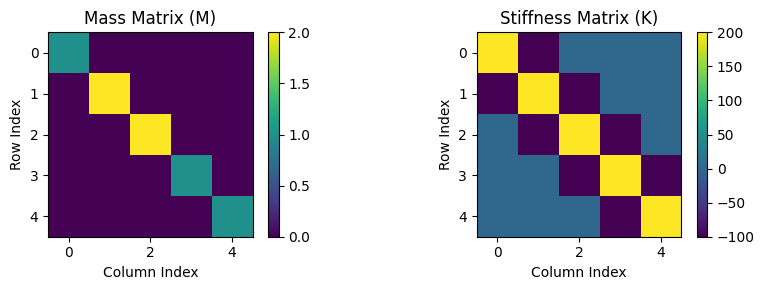

In [22]:
# Function to plot matrices as heatmaps
def plot_matrix(matrix, title):
    plt.figure(figsize=(4, 3))
    plt.imshow(np.array(matrix).astype(np.float64), cmap="viridis", interpolation="nearest")
    plt.colorbar(label="Value")
    plt.title(title)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")
    plt.show()

# Plot the matrices side by side
def plot_matrices_side_by_side(matrices, titles):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))  # 1 row, 3 columns
    for ax, matrix, title in zip(axes, matrices, titles):
        im = ax.imshow(np.array(matrix).astype(np.float64), cmap="viridis", interpolation="nearest")
        ax.set_title(title)
        ax.set_xlabel("Column Index")
        ax.set_ylabel("Row Index")
        fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Matrices and titles
matrices = [substituted_M, substituted_C, substituted_K]
titles = ["Mass Matrix (M)", "Damping Matrix (C)", "Stiffness Matrix (K)"]

# Matrices and titles
matrices = [substituted_M, substituted_K]
titles = ["Mass Matrix (M)", "Stiffness Matrix (K)"]

# Plot the matrices
plot_matrices_side_by_side(matrices, titles)


In [23]:
#convert substituted matrices to np.array
M = np.array(substituted_M).astype(np.float64)
C = np.array(substituted_C).astype(np.float64)
K = np.array(substituted_K).astype(np.float64)

$$
\begin{bmatrix}
A
\end{bmatrix}
= 

\begin{bmatrix}
\begin{bmatrix}
K
\end{bmatrix}
- 
\omega^2
\begin{bmatrix}
M
\end{bmatrix}
\end{bmatrix}
$$

In [24]:
A = np.linalg.inv(M)@K
print(A.shape)
A[:6, :6]

(5, 5)


array([[ 200., -100.,    0.,    0.,    0.],
       [ -50.,  100.,  -50.,    0.,    0.],
       [   0.,  -50.,  100.,  -50.,    0.],
       [   0.,    0., -100.,  200., -100.],
       [   0.,    0.,    0., -100.,  200.]])

#### Lastne vrednosti, oblike, sortiranje

In [25]:
w, v = np.linalg.eig(A)
idx = w.argsort()[::1]
w = w[idx]
v = v[:, idx]
print("Lastne frekvence:")
for i in range(len(w)):
    print(f"{np.sqrt(w[i]):.3f} rad/s")

Lastne frekvence:
4.078 rad/s
8.940 rad/s
12.247 rad/s
15.494 rad/s
17.702 rad/s


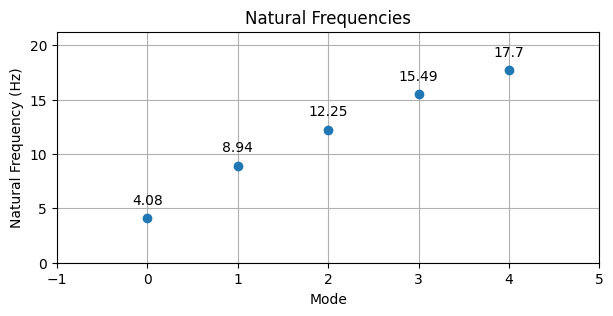

In [26]:
fig, ax = plt.subplots(figsize=(5+ n_dof*0.4, 3))
ax.plot(np.sqrt(w.real), 'o')
ax.set_xlabel('Mode')
ax.set_ylabel('Natural Frequency (Hz)')
ax.set_title('Natural Frequencies')
ax.set_ylim([0, 1.2*np.sqrt(max(w.real))])
ax.set_xlim([-1, n_dof])
for i, txt in enumerate(np.round(np.sqrt(w.real), 2)):
    ax.annotate(txt, (i, np.sqrt(w.real)[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.grid()
plt.show()

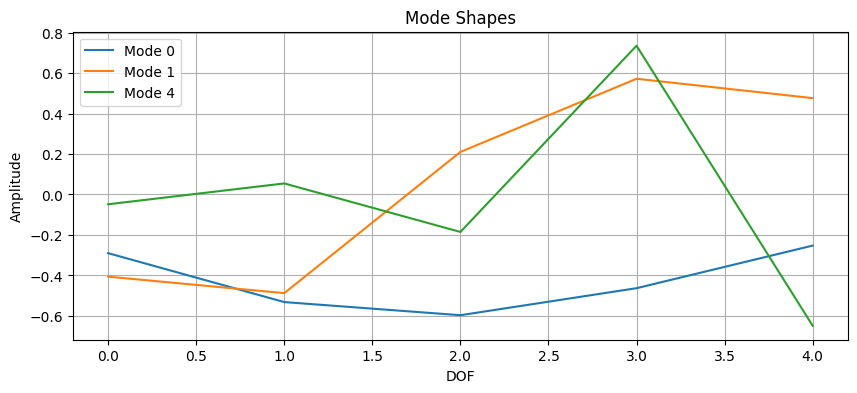

In [27]:
# plot mode shapes all in one plot only different colors. let me define which modes to show
modes = [0, 1, 4]
fig, ax = plt.subplots(figsize=(10, 4))
for i in modes:
    ax.plot(v[:, i], label=f'Mode {i}')
ax.set_xlabel('DOF')
ax.set_ylabel('Amplitude')
ax.set_title('Mode Shapes')
ax.legend()
plt.grid()
plt.show()

#### Preverjanje ortogonalnosti lastnih vektorjev

In [28]:
s = 1 #indeks 1
r = 2 #indeks 2
v[:, s].T @  M @ v[:, r]

#### Modal mass and stiffness

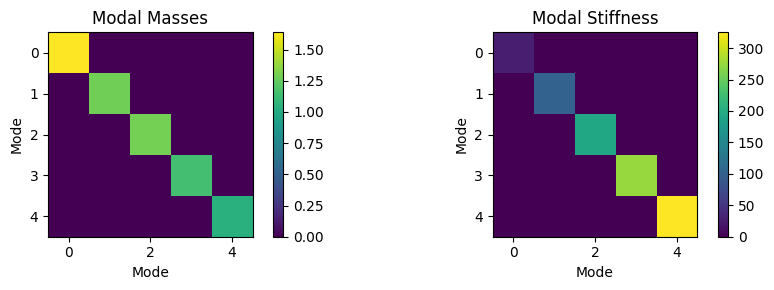

Modal Mass 0: 1.64 kg
Modal Mass 1: 1.28 kg
Modal Mass 2: 1.29 kg
Modal Mass 3: 1.15 kg
Modal Mass 4: 1.04 kg


In [29]:
#define modal stiffness and modal masses 
modal_stiffness = v.T @ K @ v
modal_masses = v.T @ M @ v
# plot modal masses and modal stiffness with imshhow
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
im1 = ax[0].imshow(modal_masses, cmap='viridis')
ax[0].set_title('Modal Masses')
ax[0].set_xlabel('Mode')
ax[0].set_ylabel('Mode')
fig.colorbar(im1, ax=ax[0], orientation='vertical')
im2 = ax[1].imshow(modal_stiffness, cmap='viridis')
ax[1].set_title('Modal Stiffness')
ax[1].set_xlabel('Mode')
ax[1].set_ylabel('Mode')
fig.colorbar(im2, ax=ax[1], orientation='vertical')
plt.tight_layout()
plt.show()


for i in range(len(modal_masses)):
    print(f'Modal Mass {i}: {modal_masses[i, i]:.2f} kg')


#### Masno normiranje

In [30]:
D = np.zeros((n_dof, n_dof))
for i in range(n_dof):
    D[i, i] = 1/np.sqrt(modal_masses[i, i])
    
Phi = v.copy()
for i in range(n_dof):
    Phi[:,i] =  Phi[:,i]*D[i,i]

### Admitanca

*Definicija vektorja frekvenc*

In [31]:
omega = np.linspace(1, 10, 10)

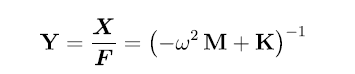

*Preverjanje razsežnosti matrik*

In [32]:
print("Oblike matrik:")
print("M:")
print(M.shape)
print("K:")
print(K.shape)
print("omega:")
print(omega.shape)

Oblike matrik:
M:
(5, 5)
K:
(5, 5)
omega:
(10,)


In [33]:
Y_einsum = np.linalg.inv(-omega[:,None,None]**2 * M[None,:,:] + K[None,:,:])
Y_einsum.shape

In [34]:
Y = np.zeros((len(omega), M.shape[0], M.shape[1]))

for i in range(len(omega)):
    Y[i] = np.linalg.inv(-omega[i]**2*M + K)

print("Y shape:")
print(Y.shape)

Y shape:
(10, 5, 5)


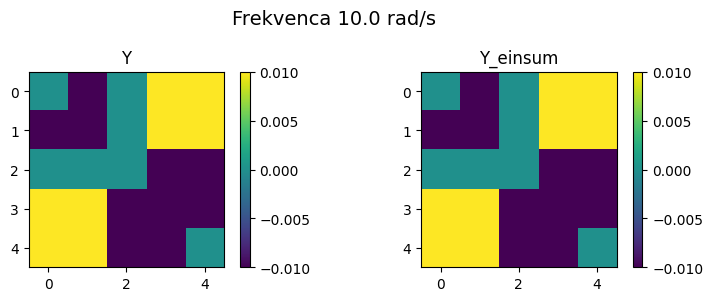

In [50]:
fig, axs = plt.subplots(ncols=2, figsize=(6 + n_dof*0.4, 3))  # Two columns for side-by-side plots

frame = 9
fig.suptitle(f'Frekvenca {omega[frame]} rad/s', fontsize=14)
# First plot on the left
im0 = axs[0].imshow(Y[frame], cmap='viridis')
fig.colorbar(im0, ax=axs[0])  # Colorbar for the first plot
axs[0].set_title('Y', fontsize=12)

# Second plot on the right
im1 = axs[1].imshow(Y_einsum[frame], cmap='viridis')  # You can change this to another array if needed
fig.colorbar(im1, ax=axs[1])  # Colorbar for the second plot
axs[1].set_title('Y_einsum', fontsize=12)

plt.tight_layout()
plt.show()

In [51]:
(Y == Y_einsum).all()

np.True_

### Admitanca 2

In [37]:
import numpy as np

modal_shapes_l_limit = 0
modal_shapes_u_limit = 2
idx_w = np.arange(modal_shapes_l_limit, modal_shapes_u_limit, 1) #index za lastne frekvence
omega_r = w[modal_shapes_l_limit:modal_shapes_u_limit] # lastne frekvence

o_l_limit = 0 # Spodnja meja output
o_u_limit = 4 # zgornja meja ouput

i_l_limit = 0 # Spodnja meja input
i_u_limit = 3 # zgornja meja input

Phi_output = Phi[o_l_limit:o_u_limit,modal_shapes_l_limit:modal_shapes_u_limit].copy()
Phi_input = Phi[i_l_limit:i_u_limit, modal_shapes_l_limit:modal_shapes_u_limit].copy()

print(f'Število modalnih oblik: {modal_shapes_u_limit - modal_shapes_l_limit}')
print(f'Oblika Phi_O: {Phi_output.shape}')
print(f'Oblika Phi_I: {Phi_input.shape}')
print(f'Oblika Phi_I.T: {Phi_input.T.shape}')
print(f'Omega: {omega_r.shape}')

Število modalnih oblik: 2
Oblika Phi_O: (4, 2)
Oblika Phi_I: (3, 2)
Oblika Phi_I.T: (2, 3)
Omega: (2,)


$
\mathbf{Y} \approx \frac{\mathbf{\Phi} \mathbf{\Phi}^{\top}}{-\omega^2 \mathbf{I} + \omega_r^2}
= \sum_{r=1}^{m} \frac{r \, \boldsymbol{\phi}_r \boldsymbol{\phi}_r^{\top}}{-\omega^2 + \omega_r^2}
= \sum_{r=1}^{m} \frac{r \mathbf{A}}{-\omega^2 + \omega_r^2},
$


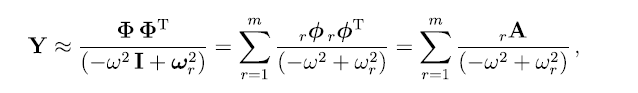

In [38]:
Phi_output.shape, Phi_input.shape, Phi_input.T.shape, (Phi_output@Phi_input.T).shape

In [39]:
np.einsum('om, im -> moi', Phi_output, Phi_input).shape

In [40]:
Phi_input[:, [0]].shape

In [41]:
Phi_output[:, [0]] @ Phi_input[:, [0]].T

array([[0.05128039, 0.09403291, 0.10551034],
       [0.09403291, 0.17242827, 0.19347446],
       [0.10551034, 0.19347446, 0.21708948],
       [0.08189532, 0.15017155, 0.16850113]])

In [42]:
Y_2 = np.zeros((len(omega), Phi_output.shape[0], Phi_input.shape[0]))
# Y_2_einsum = np.zeros((len(omega), Phi_output.shape[0], Phi_input.shape[0]))

for i in np.arange(len(omega)):
    for j in np.arange(modal_shapes_l_limit, modal_shapes_u_limit, 1):
        # r_A = np.einsum('om, im -> moi', Phi_output, Phi_input)[j]
        r_A = Phi_output[:, [j]] @ Phi_input[:, [j]].T
        r_B = 1. / (-omega[i]**2 + omega_r[j]**2)
        Y_2[i] += r_A * r_B
    
Y_2.shape

In [43]:
stevec = np.einsum('om, im -> moi', Phi_output, Phi_input)
imenovalec = 1. / (-omega[:,None]**2 + omega_r**2)
kvocient = np.einsum('moi, fm -> foi', stevec, imenovalec)
kvocient.shape

In [44]:
# Y_2_einsum = np.einsum('om, im, fm -> foi', Phi_output, Phi_input, 1. / (-omega[:,None]**2 + omega_r**2))
# Y_2_einsum.shape
Y_2_einsum = Admitanca(w, omega, Phi, modal_shapes_l_limit = 0, modal_shapes_u_limit = 5,o_l_limit = 0, o_u_limit = 5, i_l_limit = 0, i_u_limit = 5)


NameError: name 'Admitanca' is not defined

In [ ]:
(Y_2 == Y_2_einsum).all()

np.True_

In [ ]:
(kvocient == Y_2).all()

np.False_

In [ ]:
(-omega[1]**2 + omega_r**2)

array([  272.55245364,  6385.18992316, 22496.        , 57625.27719568,
       98200.98042752])

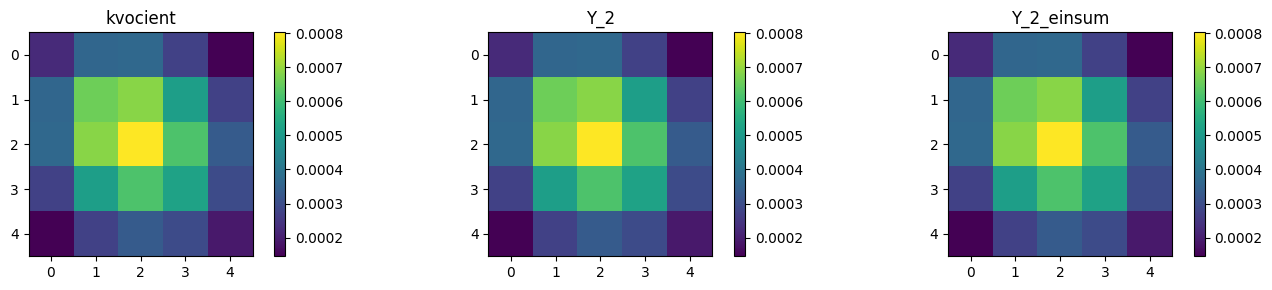

In [ ]:
# (Y_2 == Y_2_einsum).all()
fig, axs = plt.subplots(ncols=3, figsize=(12 + n_dof*0.4, 3))  # Two columns for side-by-side plots

frame = 0
# First plot on the left
im0 = axs[0].imshow(kvocient[frame], cmap='viridis')
fig.colorbar(im0, ax=axs[0])  # Colorbar for the first plot
axs[0].set_title('kvocient')

# Second plot on the right
im1 = axs[1].imshow(Y_2[frame], cmap='viridis')  # You can change this to another array if needed
fig.colorbar(im1, ax=axs[1])  # Colorbar for the second plot
axs[1].set_title('Y_2')

# First plot on the left
im0 = axs[2].imshow(Y_2_einsum[frame], cmap='viridis')
fig.colorbar(im0, ax=axs[2])  # Colorbar for the first plot
axs[2].set_title('Y_2_einsum')

plt.tight_layout()
plt.show()

In [ ]:
Y_vse_einsum = Admitanca(w, omega, Phi, 0, 5, 0, 5, 0, 5)

Admitanca -> shape: (10, 5, 5)


In [ ]:
(kvocient[9] == Y_2[9])

array([[ True,  True,  True,  True, False],
       [ True,  True, False, False, False],
       [ True, False,  True,  True,  True],
       [ True, False,  True,  True,  True],
       [False, False,  True,  True,  True]])

C:\Users\marko\AppData\Local\Temp\ipykernel_38016\3846517847.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 900x300 with 4 Axes> than <Figure size 1400x300 with 6 Axes> which fig.colorbar is called on.
  fig.colorbar(im2, ax=axs[2])


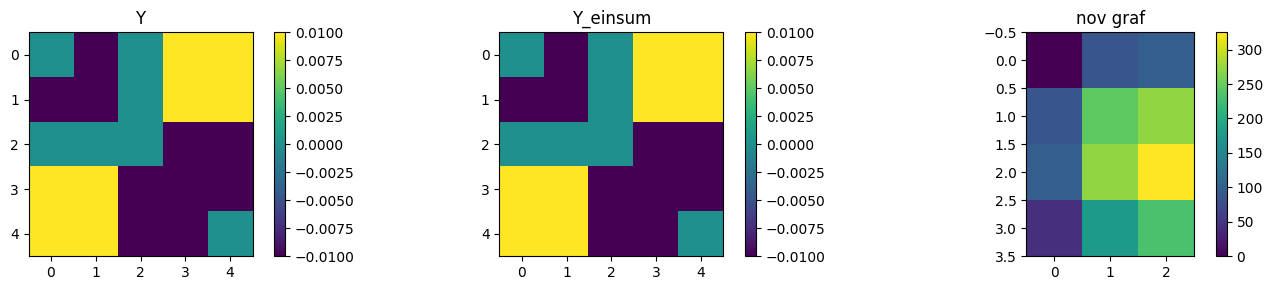

In [61]:
# (Y_2 == Y_2_einsum).all()
fig, axs = plt.subplots(ncols=3, figsize=(12 + n_dof*0.4, 3))  # Two columns for side-by-side plots

frame = 9
# First plot on the left
im0 = axs[0].imshow(Y[frame], cmap='viridis')
fig.colorbar(im0, ax=axs[0])  # Colorbar for the first plot
axs[0].set_title('Y')

# Second plot on the right
im1 = axs[1].imshow(Y_einsum[frame], cmap='viridis')  # You can change this to another array if needed
fig.colorbar(im1, ax=axs[1])  # Colorbar for the second plot
axs[1].set_title('Y_einsum')

# First plot on the left
im0 = axs[2].imshow(kvocient[frame], cmap='viridis')
fig.colorbar(im2, ax=axs[2]) 
axs[2].set_title('nov graf')

plt.tight_layout()
plt.show()

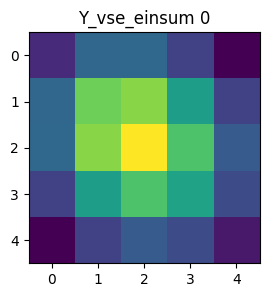

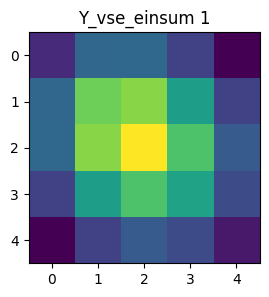

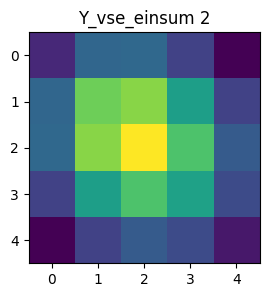

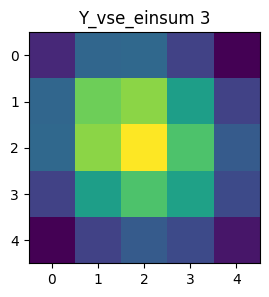

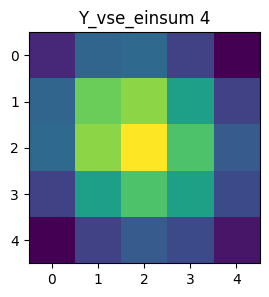

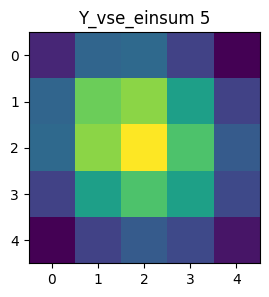

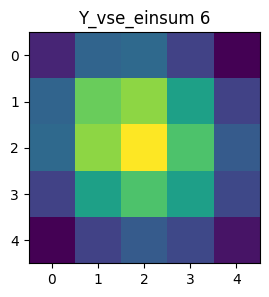

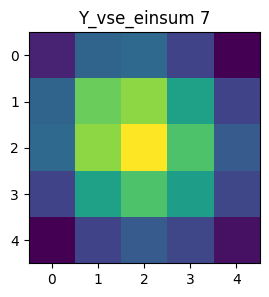

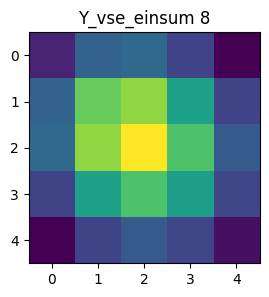

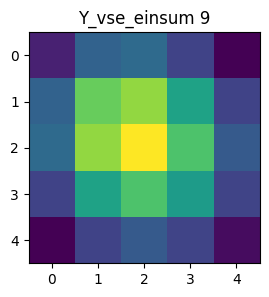

In [ ]:
for i in np.arange(len(omega)):
    fig, ax = plt.subplots(figsize=(5+ n_dof*0.4, 3))
    ax.imshow(Y_2[i], cmap='viridis')
    ax.set_title(f'Y_vse_einsum {i}')

In [54]:
diameter = 12756 # km
diameter_m = diameter * 1000 # m
obseg_m = np.pi * diameter_m # m
print(f'Obseg: {obseg_m:.2f} m')

Obseg: 40074155.89 m


In [55]:
nov_obseg = obseg_m + 1
print(f'Nov obseg: {nov_obseg:.2f} m')
print(f'Obseg: {obseg_m:.2f} m')

Nov obseg: 40074156.89 m
Obseg: 40074155.89 m


In [57]:
polmer_m = diameter_m / 2 # m 
print(f'Polmer: {polmer_m:.2f} m') 

Polmer: 6378000.00 m


In [59]:
nov_polmer_m = nov_obseg / (2 * np.pi) # m
print(f'Nov polmer: {nov_polmer_m:.2f} m')

razlika = nov_polmer_m - polmer_m # m
razlika_cm = razlika * 100 # cm
razlika_cm

Nov polmer: 6378000.16 m
